In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [5]:
df = pd.read_csv("svm_student_placement_dataset.csv")

In [6]:
df.head()

,hours_studied,attendance_percent,cgpa,placed
0,2,55,5.2,0
1,3,60,5.5,0
2,4,65,6.0,0
3,5,70,6.5,0
4,6,75,7.0,1


In [7]:
X = df[["hours_studied", "attendance_percent", "cgpa"]]
y = df["placed"]

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42)

In [10]:
model = SVC(
    kernel="rbf",   # Non-linear boundary
    C=1,            # Soft margin
    gamma="scale"   # Stable curvature
)
model.fit(X_train, y_train)

SVC(C=1)

In [11]:
y_pred = model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[5 0]
 [0 7]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         7

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



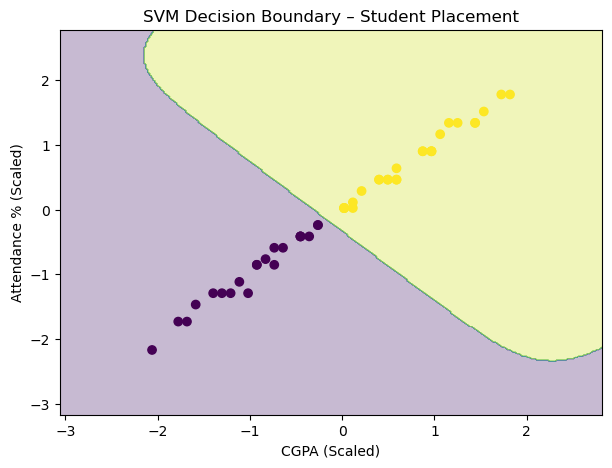

In [12]:
# Select 2 features for visualization
X_vis = df[["cgpa", "attendance_percent"]]
y_vis = df["placed"]

# Scale again for visualization
scaler_vis = StandardScaler()
X_vis_scaled = scaler_vis.fit_transform(X_vis)

# Train SVM on 2 features
model_vis = SVC(kernel="rbf", C=1, gamma="scale")
model_vis.fit(X_vis_scaled, y_vis)

# Create mesh grid
xx, yy = np.meshgrid(
    np.linspace(X_vis_scaled[:,0].min()-1, X_vis_scaled[:,0].max()+1, 300),
    np.linspace(X_vis_scaled[:,1].min()-1, X_vis_scaled[:,1].max()+1, 300)
)

# Predict for each point in grid
Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_vis_scaled[:,0], X_vis_scaled[:,1], c=y_vis)
plt.xlabel("CGPA (Scaled)")
plt.ylabel("Attendance % (Scaled)")
plt.title("SVM Decision Boundary – Student Placement")
plt.show()
